In [1]:
# System and path configuration
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Core LSD imports
from codes.lsd_train import LSD
from codes.utils import (
    plot_random_walks,
    cross_boundary_correctness,
)
from codes.config import LSDConfig


# Scientific computing
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Deep learning
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['svg.fonttype'] = 'none'  # Use text instead of paths for fonts
sns.set_style('white')
sns.set_palette('husl')

print("Environment configured successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

Environment configured successfully!
Python version: 3.8.10
PyTorch version: 2.4.1+cu121
Scanpy version: 1.9.8


In [2]:
# Configure computational device
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check GPU details if available
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda:3
GPU Name: NVIDIA GeForce RTX 3090
GPU Memory: 25.44 GB
CUDA Version: 12.1


In [3]:
# Load preprocessed pancreas data with prior pseudotime
print("Loading pancreatic endocrine development dataset...")
data_path = "../../data/Pancreas/adata_prior_time.h5ad"
adata = sc.read(data_path)

print("Dataset loaded successfully!")
print(f"Data path: {data_path}")
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAvailable data layers: {list(adata.layers.keys())}")
print(f"Cell metadata columns: {list(adata.obs.columns)}")
print(f"Cell-cell matrices: {list(adata.obsp.keys())}")

# Display cell type distribution
print(f"\nCell type distribution:")
print("="*50)
cluster_counts = adata.obs['clusters'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / adata.n_obs) * 100
    print(f"  {cluster:15s}: {count:5,} cells ({percentage:5.1f}%)")

# Check for prior information
if 'prior_time' in adata.obs.columns:
    print(f"\nPrior pseudotime available: {adata.obs['prior_time'].notna().sum()} cells have values")
    print(f"  Min: {adata.obs['prior_time'].min():.3f}")
    print(f"  Max: {adata.obs['prior_time'].max():.3f}")

Loading pancreatic endocrine development dataset...
Dataset loaded successfully!
Data path: ../../data/Pancreas/adata_prior_time.h5ad
Number of cells: 16,822
Number of genes: 5,000

Available data layers: ['raw', 'spliced', 'unspliced']
Cell metadata columns: ['sample', 'clusters', 'prior_time', 'librarysize']
Cell-cell matrices: ['connectivities', 'distances']

Cell type distribution:
  Alpha          : 1,159 cells (  6.9%)
  Beta           :   936 cells (  5.6%)
  Delta          :   239 cells (  1.4%)
  Ductal         : 3,717 cells ( 22.1%)
  Epsilon        :   290 cells (  1.7%)
  Fev+           : 1,298 cells (  7.7%)
  Fev+ Alpha     :   333 cells (  2.0%)
  Fev+ Beta      : 1,439 cells (  8.6%)
  Fev+ Delta     :   296 cells (  1.8%)
  Ngn3 high      : 3,586 cells ( 21.3%)
  Ngn3 low       : 1,609 cells (  9.6%)
  Prlf. Ductal   : 1,920 cells ( 11.4%)

Prior pseudotime available: 16822 cells have values
  Min: 0.000
  Max: 1.000


In [4]:
# Define the pancreatic endocrine differentiation phylogeny
# This represents the established developmental progression
phylogeny = {
    "Prlf. Ductal":      ["Ductal"],                    # Proliferating to quiescent ductal
    "Ductal":            ["Ngn3 low"],                  # Ductal to early endocrine progenitor
    "Ngn3 low":          ["Ngn3 high"],                 # Progenitor maturation
    "Ngn3 high":         ['Fev+','Fev+ Delta','Epsilon'], # Multi-lineage branching
    "Fev+":              ['Fev+ Alpha','Fev+ Beta'],    # Alpha/Beta lineage split
    "Fev+ Delta":        ["Delta"],                     # Delta maturation
    "Fev+ Alpha":        ["Alpha"],                     # Alpha maturation
    "Fev+ Beta":         ["Beta"],                      # Beta maturation
    "Epsilon":           [],                            # Terminal epsilon cells
    "Alpha":             [],                            # Terminal alpha cells (glucagon)
    "Beta":              [],                            # Terminal beta cells (insulin)
    "Delta":             [],                            # Terminal delta cells (somatostatin)
}


# Validate phylogeny coverage
phylo_clusters = set(phylogeny.keys())
data_clusters = set(adata.obs['clusters'].unique())

## Section 7: Model Initialization

In [5]:
# Initialize the LSD model
print("Initializing LSD model for pancreatic endocrine development...")
print("="*60)
cfg = LSDConfig()

cfg.model.V_coeff = 5e-3
cfg.optimizer.kl_schedule.af = 3
cfg.optimizer.adam.lr = 2e-3
cfg.walks.batch_size = 256
cfg.walks.path_len = 50
cfg.walks.random_state = SEED

# Set random seed before model initialization for reproducibility
pyro.set_rng_seed(SEED)


lsd = LSD(
    adata,                           # Single-cell expression data
    cfg,             # Length of trajectory walks
    device=device,                   # Computation device (GPU/CPU)
    lib_size_key="librarysize",      # Column name for library sizes
    raw_count_key="raw",             # Layer name for raw counts
)

print("\n✓ Model initialized successfully!")
print(f"\nModel Configuration:")
print(f"  Latent dimension (z): {lsd.z_dim}")
print(f"  Differentiation dimension (B): {lsd.B_dim}")
print(f"  Potential regularization: {lsd.lsd.V_coeff}")
print(f"  Device: {lsd.device}")

Initializing LSD model for pancreatic endocrine development...

✓ Model initialized successfully!

Model Configuration:
  Latent dimension (z): 10
  Differentiation dimension (B): 2
  Potential regularization: 0.005
  Device: cuda:3


In [6]:

# Set phylogenetic relationships
lsd.set_phylogeny(phylogeny, cluster_key="clusters")

# Check if prior pseudotime is available and set prior transitions
if "prior_time" in adata.obs.columns:
    print("\nSetting prior transition matrix from pseudotime...")
    lsd.set_prior_transition(prior_time_key="prior_time")
    print("✓ Prior transition matrix incorporated")
    print(f"  Cells with prior time: {adata.obs['prior_time'].notna().sum()}")
else:
    print("\n⚠ No prior pseudotime found, using phylogeny constraints only")

print("\n✓ All biological constraints successfully incorporated")


Setting prior transition matrix from pseudotime...
[LSD] Removing 52 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.
✓ Prior transition matrix incorporated
  Cells with prior time: 16822

✓ All biological constraints successfully incorporated


Generating random walk trajectories...

✓ Random walks generated successfully!
  Walk tensor shape: torch.Size([4096, 50])

Visualizing random walks on UMAP...


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


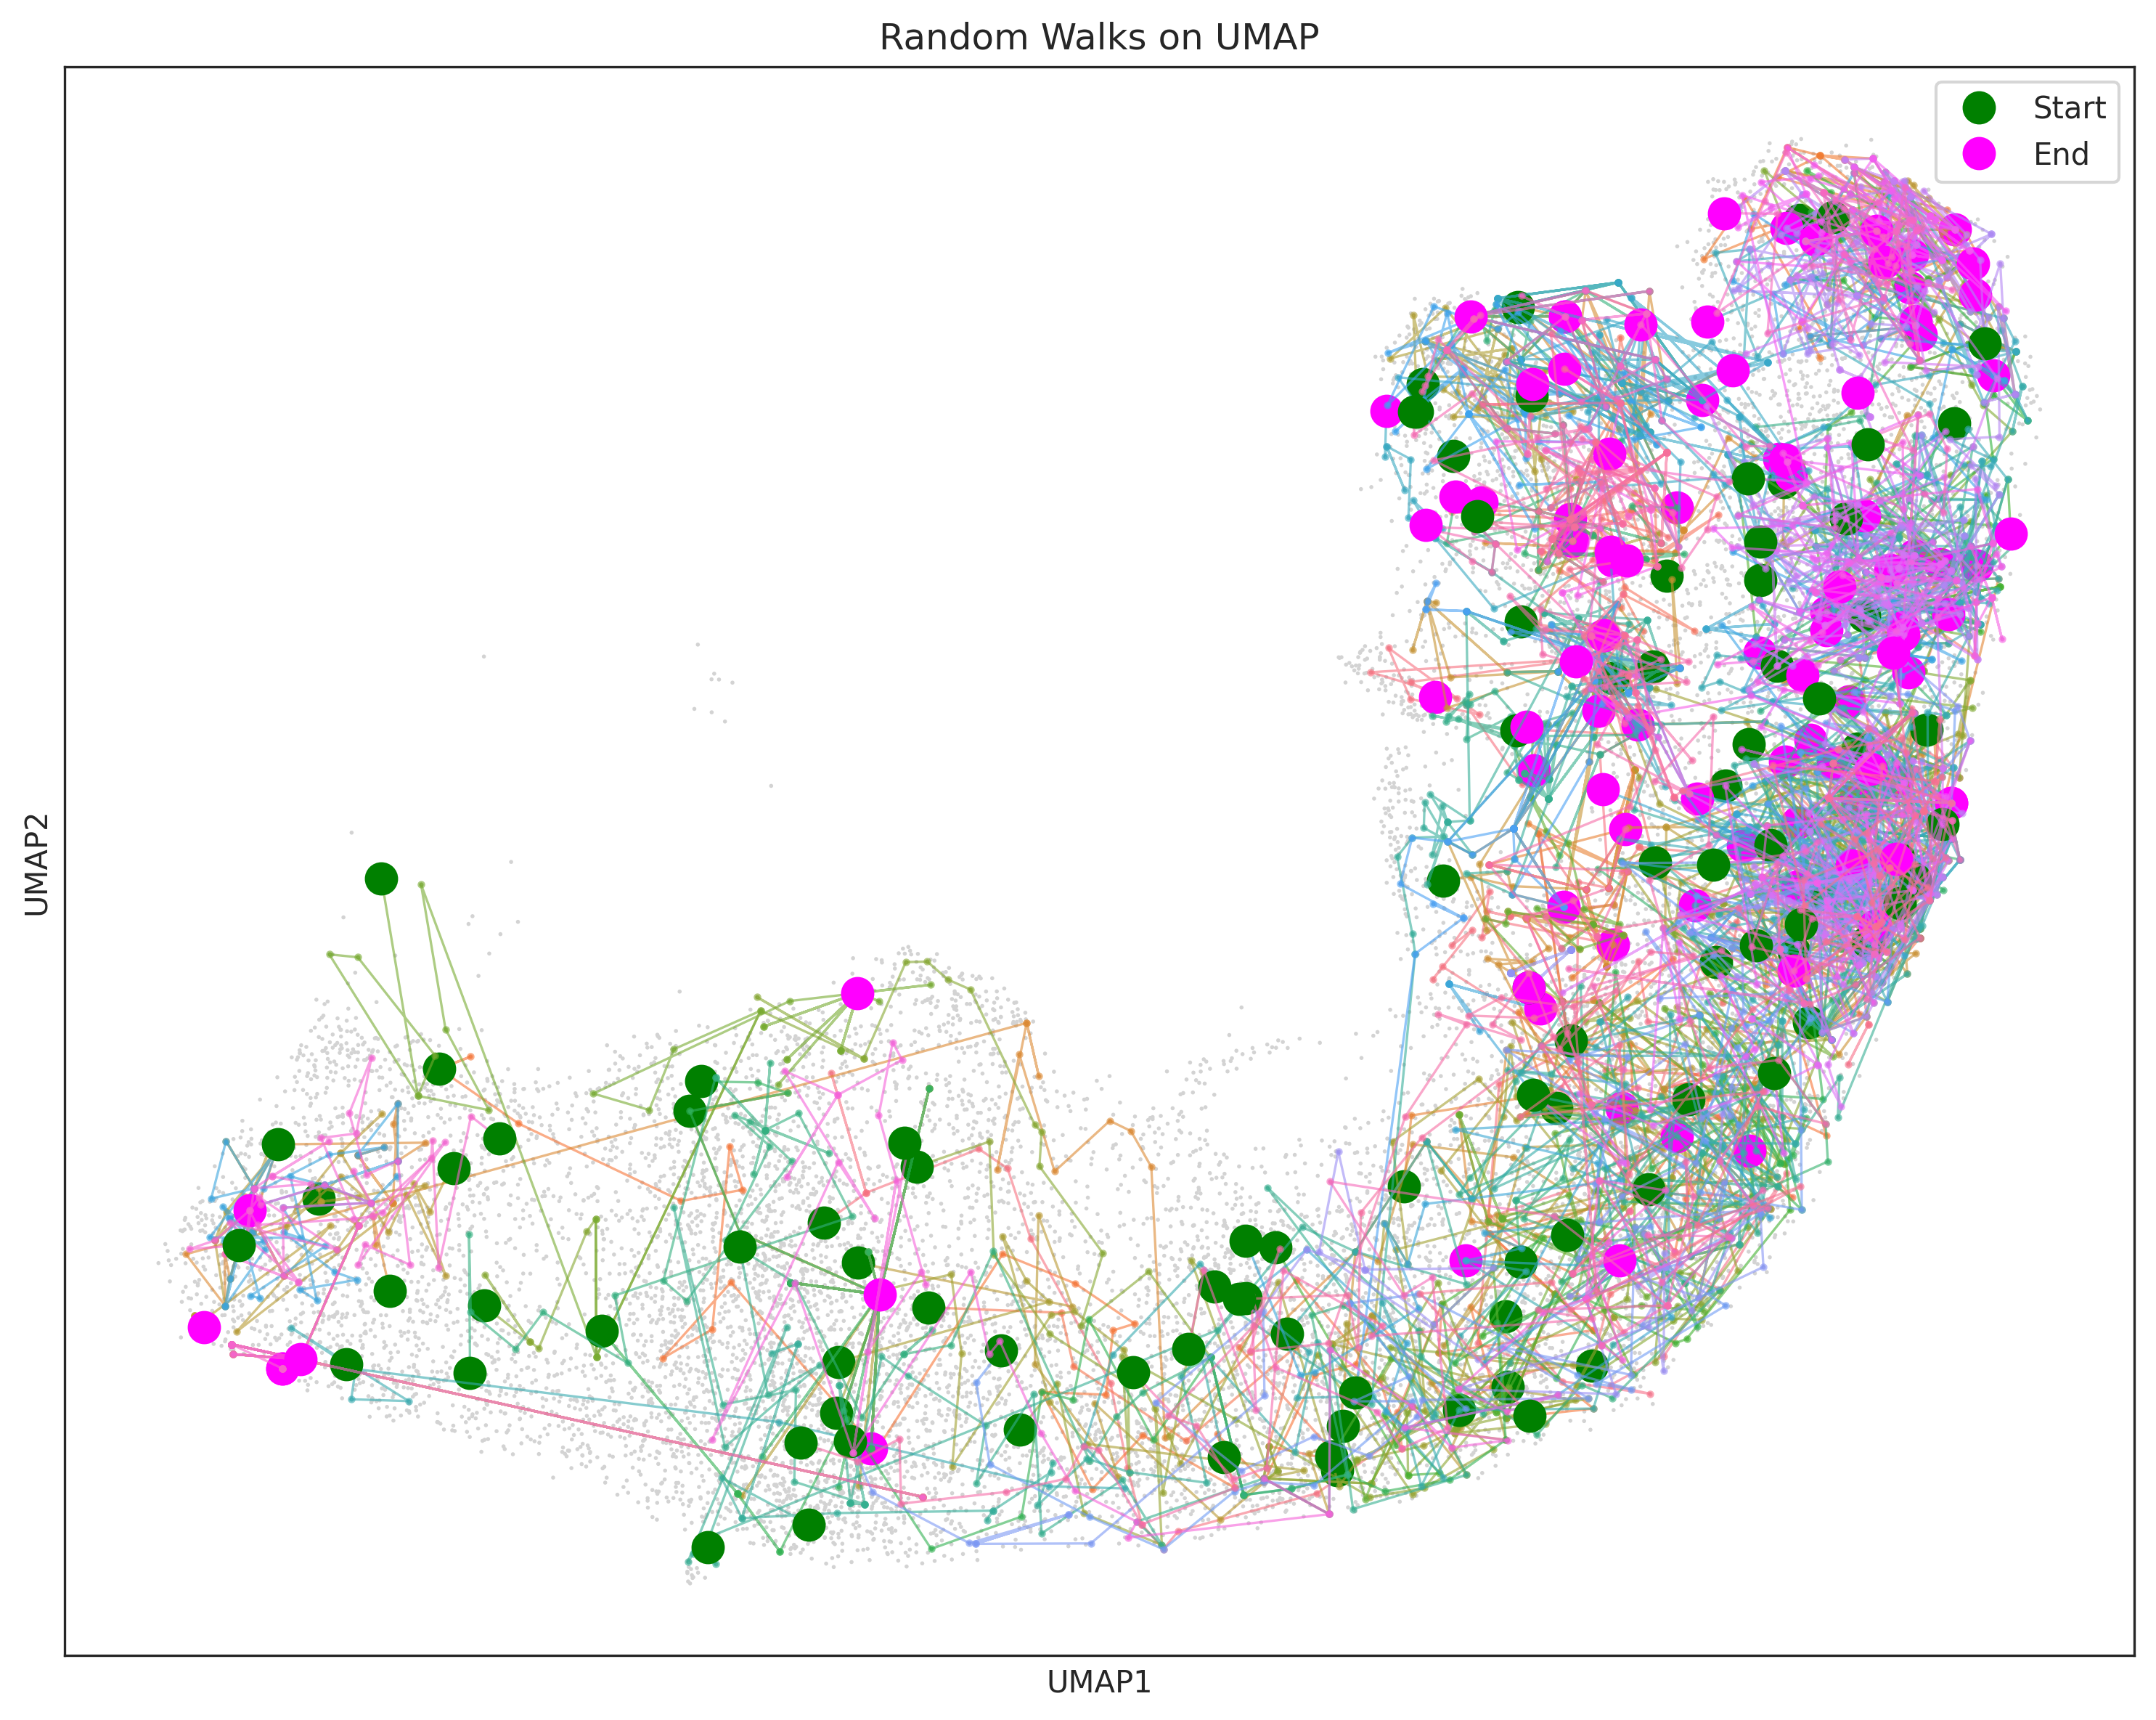

In [8]:
# Generate random walks for training
print(f"Generating random walk trajectories...")

# Prepare walks on the cell connectivity graph
lsd.prepare_walks()

print(f"\n✓ Random walks generated successfully!")
print(f"  Walk tensor shape: {lsd.walks.shape}")


# Visualize a subset of random walks
if "X_umap" in lsd.adata.obsm:
    print("\nVisualizing random walks on UMAP...")
    plot_random_walks(lsd.adata, lsd.walks[:100], "X_umap")  # Show first 100 walks



Starting model training...
Training for 100 epochs
This may take 20-30 minutes on GPU...


Training Epochs: 100%|██████████| 100/100 [22:29<00:00, 13.50s/it, -ELBO=1.4282, Potential Metric=0.2799, Entropy Metric=0.0592]


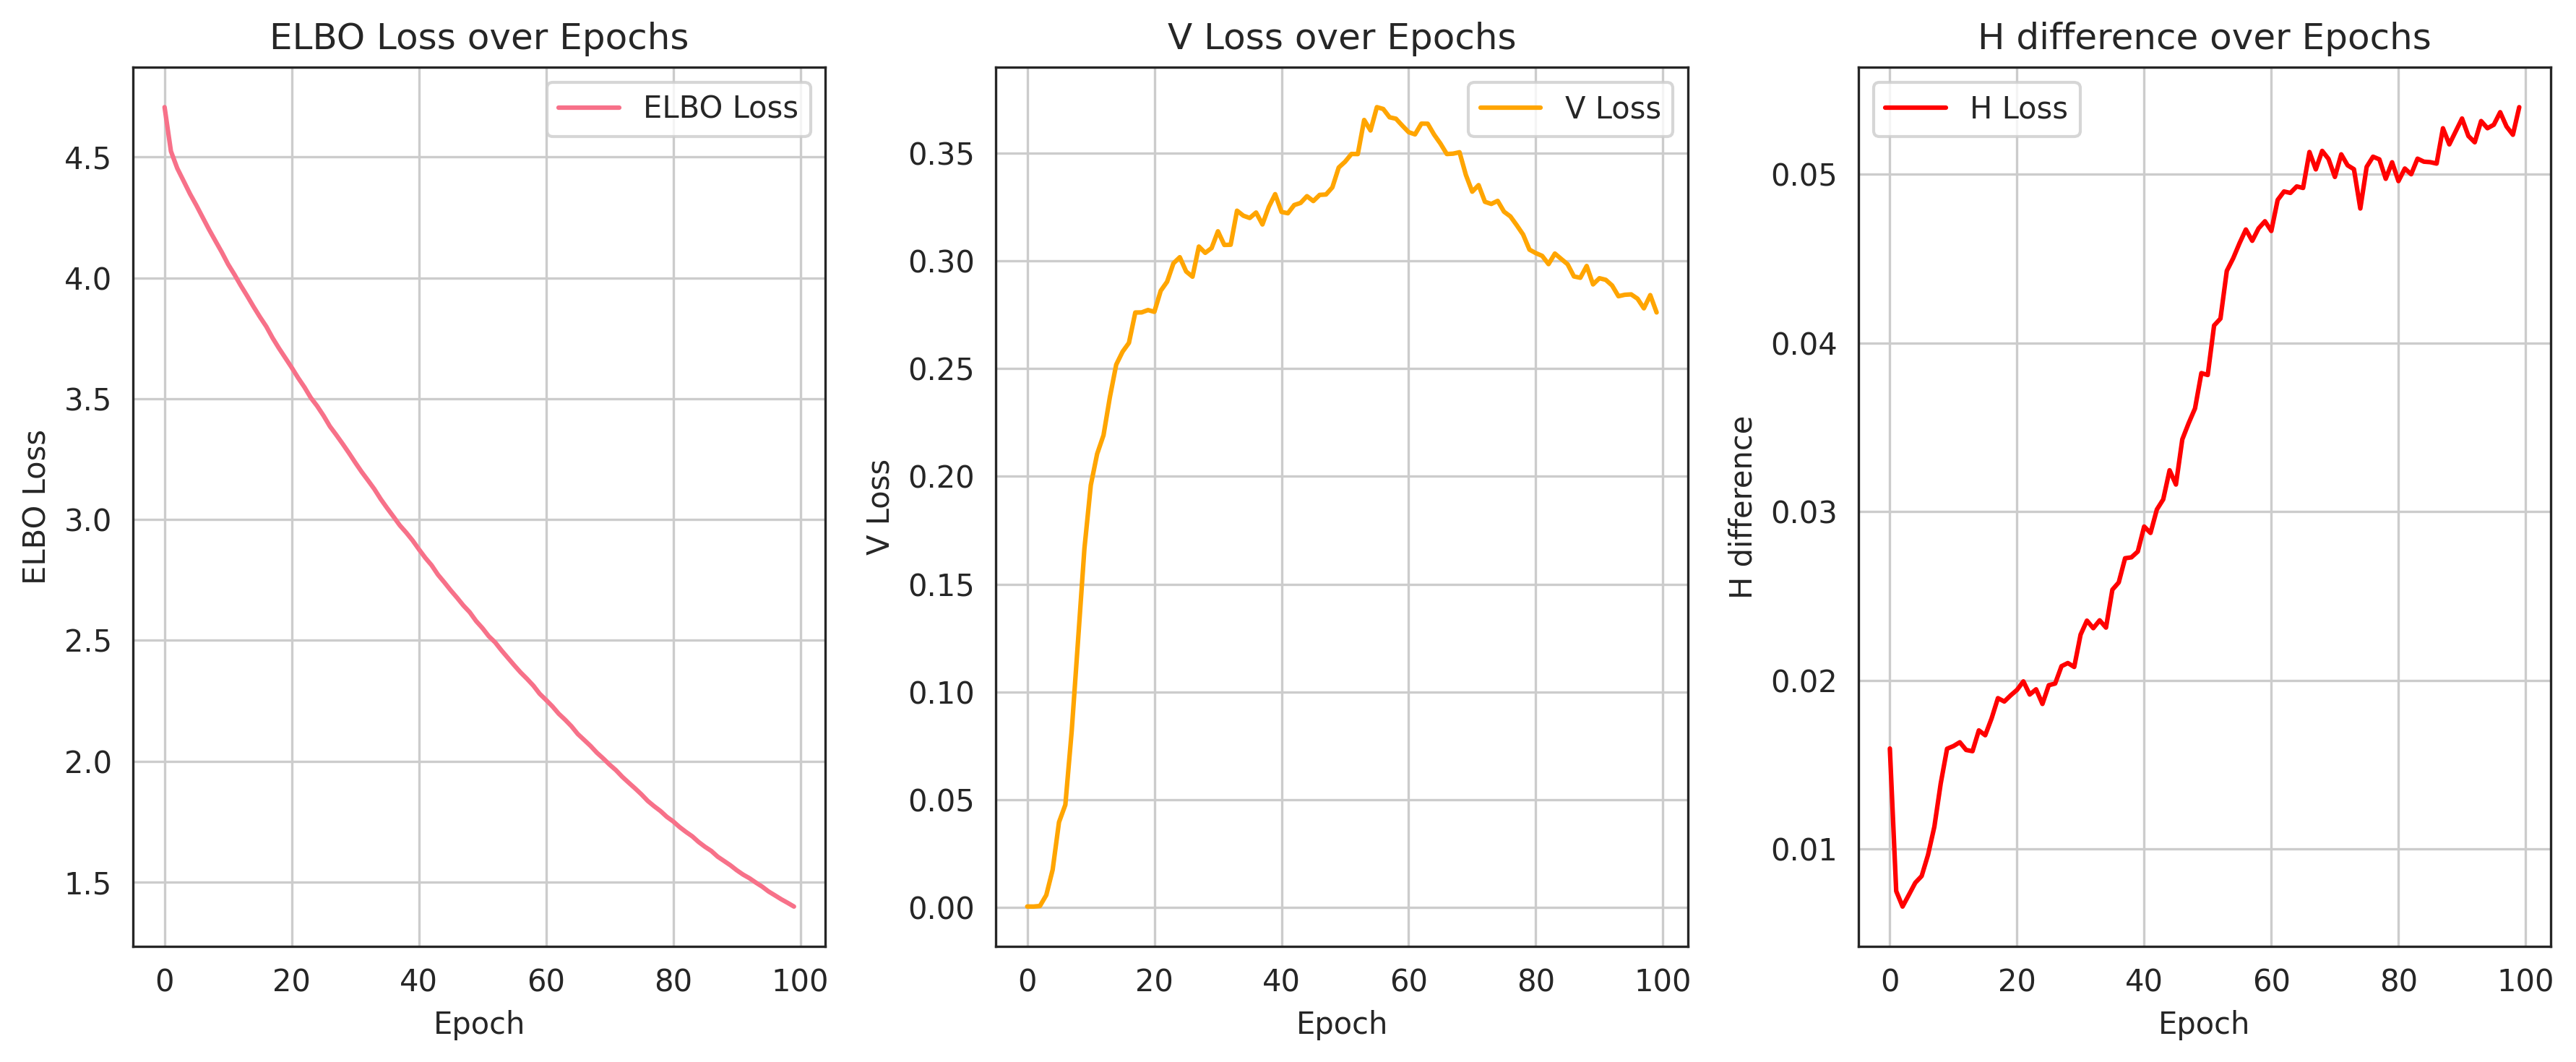


✓ Training completed successfully!


In [9]:
# Define model directory based on hyperparameters
model_dir = "../../Models/Pancreas_model"

print("\nStarting model training...")
print("="*60)

# Clear parameter store for fresh training
pyro.clear_param_store()

# Create save directory
os.makedirs(model_dir, exist_ok=True)
num_epochs = 100     # Total training epochs

print(f"Training for {num_epochs} epochs")
print("This may take 20-30 minutes on GPU...")
# Train the model
lsd.train(
    num_epochs=num_epochs,
    save_dir=model_dir,
    random_state=SEED
)

print("\n" + "="*60)
print("✓ Training completed successfully!")
print("="*60)